# Predicting Student Dropout and Academic Success

### Introduction
Student performance is the ultimate indicator for an educational institution to measure the quality of the services provided. Nowadays the studies offert is rich on multiple options and levels of expertise on the domains that form the job market. Analyzing how students perform is mandatory for institutions in order to improve and understand trends on the new genereations.

These will be the steps towards the project goals:

1. Setup and feature inspection
2. Exploratory Data Analysis
3. Data Preparation
4. Machine Learning model deployment
5. Fine-tuning
6. Evalution and Conclusions


## 1. Setup and Feature Inspection

### 1.1 Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
print(df.shape)
print(df.columns)

(4424, 35)
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without e

The dataset has 4424 entries corresponding to student information.

It also contains 35 features, which will be treated in depth next in order to make a full picture of all the data.

### 1.2 Feature Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

### 2.2. Correlation

To ensure a correct work for classification models, the no multicollinearity assumption needs to be fullfilled. That can be checked by a correlation analysis.

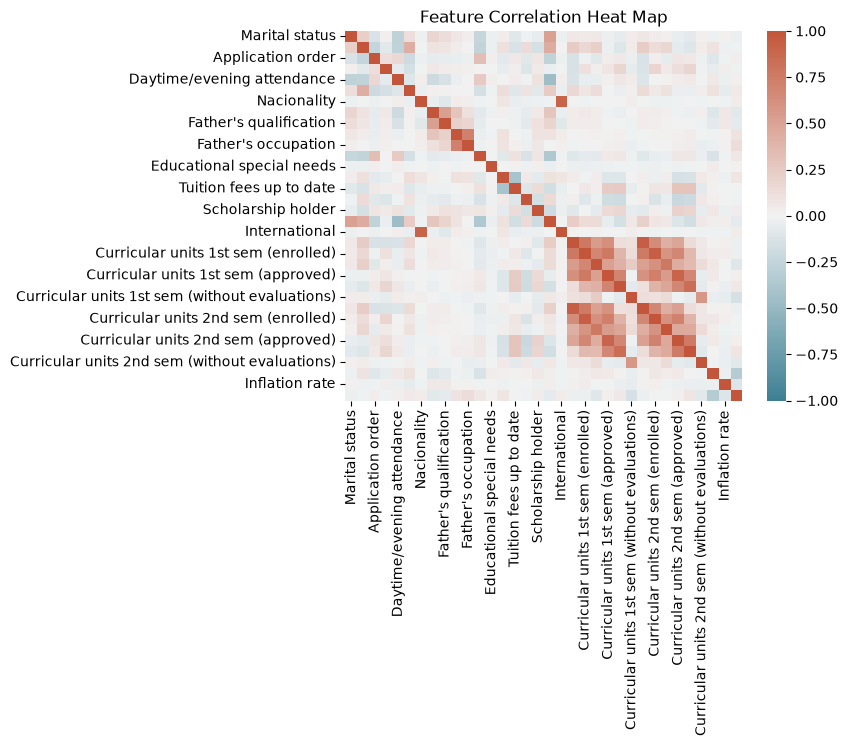

In [4]:
data_matrix = df.drop(['Target'], axis=1)
classes = df['Target']

corr_matrix = data_matrix.corr()
red_blue = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_matrix, vmin= -1, vmax= 1, cmap=red_blue)
plt.title('Feature Correlation Heat Map', fontsize= 12)
plt.show()


In [5]:
# Generate a list of highly correlated pair of features and their correlation value

threshold = 0.7

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
# Filter by threshold
real_corr = corr_pairs[corr_pairs > threshold]
print(real_corr)

Curricular units 1st sem (credited)     Curricular units 2nd sem (credited)       0.944811
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (enrolled)       0.942627
Nacionality                             International                             0.911724
Curricular units 1st sem (approved)     Curricular units 2nd sem (approved)       0.904002
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837170
Curricular units 1st sem (evaluations)  Curricular units 2nd sem (evaluations)    0.778863
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774344
Curricular units 1st sem (enrolled)     Curricular units 1st sem (approved)       0.769083
Curricular units 2nd sem (approved)     Curricular units 2nd sem (grade)          0.760804
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (credited)       0.753747
Curricular units 1st sem (approved)     Curricular units 2nd sem (enrolled)       0.733772

These are the highly correlated pair of features in the dataset. To avoid redundancy and fullfill the no multicollinearity assumption, one of each pair will be dropped.

The way to proceed will be:

* Nationality - International: International will be dropped, as Nationality contains more information (21 labels compared to a binary category)
* Mother's occupation -  Father's occupation: as both features contain similar information, Father's occupation will be dropped.
* Rest of features (Curricular units): the second feature in each pair will be dropped.

In [6]:
high_corr_pairs = [
    ("Curricular units 1st sem (credited)", "Curricular units 2nd sem (credited)"),
    ("Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (enrolled)"),
    ("Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"),
    ("Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)"),
    ("Curricular units 1st sem (evaluations)", "Curricular units 2nd sem (evaluations)"),
    ("Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)"),
    ("Curricular units 1st sem (enrolled)", "Curricular units 1st sem (approved)"),
    ("Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)"),
    ("Curricular units 1st sem (enrolled)", "Curricular units 2nd sem (credited)"),
    ("Curricular units 1st sem (approved)", "Curricular units 2nd sem (enrolled)"),
    ("Curricular units 2nd sem (enrolled)", "Curricular units 2nd sem (approved)")
]

to_drop = set()

# Drop the second feature in each pair (to avoid dropping both if a feature appears twice)
for a, b in high_corr_pairs:
    if b not in to_drop and a not in to_drop:
        to_drop.add(b)

to_drop.update(['International', "Father's occupation"])

# Drop from your DataFrame
df_reduced = df.drop(columns=to_drop)

In [7]:
df_reduced.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Displaced', 'Educational special needs',
       'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP', 'Target'],
      dtype='str')

## Key Takeaways from EDA:
- The main dropout risk factors are being older, non-single, female, from low-education backgrounds, having debt, not paying tuition, enrolling/passing few units, and coming from certain courses or entry modes.
- The dataset is highly imbalanced and this must be addressed in predictive modeling.
- Some features (macro indicators, scholarships, special needs) show little impact in this univariate view.

## 3. Data Preparation

For the Machine Learning models to work correctly, first the Data needs to be handled for them to perform.

### 3.1. Data Tidying

Issues encountered during the Exploratory Data Analysis need to be solved in order to have clean data to work on. Two were encountered:

* `Father's Ocuppation:` There was an unlabelled ID (46). To solve it a new category was attached to that id, named **'Unknown'**.

* `Application Order:` There's only one entry attached to the value **0**. This is probably due to an error when that student's information was registered.
                       To solve it there are two possible aproachs: to delete the entry entirely or to relabel the entry to other possible value. In this case the most frequent value is **1** with 68.4% of students, so this would be the safest option and the one chosen.

In [8]:
df_reduced['Application order'] = df_reduced['Application order'].replace(0, 1)

### 3.2. Train - Test Split

To avoid data leakage, the train and test subsets are splitted first. For the preservation of the **Target** distribution, the split is stratified on that variable.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df_reduced.drop(['Target'], axis=1)
y = df_reduced['Target']

#Fit LabelEncoder (will be used for XGBoost and CatBoost)
le = LabelEncoder()
le.fit(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

### 3.3. Outliers

Outliers need to be handled in order to prevent excesive noise in the dataframe and keep an homogeneous data structure. This will increase the machine learning algorithms' performance.

In [10]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(random_state=42)
outlier_pred = iso_forest.fit_predict(X_train)

mask = outlier_pred == 1
X_train_clean = X_train.iloc[mask]
y_train_clean = y_train.iloc[mask]

To keep a realistic view and representing real data, the test set will be untouched so the models can be evaluated in the original structure of the data.

### 3.4. Encoding - Standarizing

As mentioned before, for the Machine Learning Algorithms to work correctly, the data needs to be standarized and/or encoded to satisfy the requirements of the models that will be used.

During the Exploratory Data Analyisis, the data was found to be of integer of floating type. Further in the analysis, the data type of each feature was described, composing the Dataframe of:

1. `Categorical Features:` these are the features containing categories, each category labelled as IDs. These type of features need to be encoded, but there's a significant amount of IDs per feature, and encoding all of them would increase the Dataset's dimensions to the point of leading to high dimensionality problems. This is the approach selected to deal with that:

* **Low cardinal categorical** (<10 unique values) - **One Hot Encoding:** a dummy variable for each value of the categorical feature is created.

* **High cardinal categorical** (>10 unique values) - **Target Encoding:** the numerical values of each category is replaced with a blend of the posterior probability of the target given a particular categorical value and the prior probability of the target over all the training data.

2. `Numeric Features:` these are features composed just of numbers (ex.'Age at Enrollment'). This type of data needs to be scaled, for that **Standard Scaling** will be used.

3. `Binary Features:` these are features composed of 2 values (ex. Gender). As they are already encoded as 0s and 1s, no further treatment is needed.

In [11]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [14]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

low_card_cols = ['Marital status', 'Unemployment rate', 'Inflation rate', 'GDP']  # <10 unique values
high_card_cols = ['Application mode', 'Course', 'Previous qualification', 'Nacionality',
                  "Mother's qualification", "Father's qualification", "Mother's occupation"]  # >10 unique values

numeric_cols = ['Application order', 'Age at enrollment', 'Curricular units 1st sem (credited)',
                'Curricular units 1st sem (evaluations)',
                'Curricular units 1st sem (approved)',
                'Curricular units 1st sem (grade)',
                'Curricular units 1st sem (without evaluations)',
                'Curricular units 2nd sem (without evaluations)']
binary_cols = ['Daytime/evening attendance', 'Displaced', 'Educational special needs',
               'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder' ]

# Target encoding for high-cardinality
target_enc = TargetEncoder(cols=high_card_cols)

# One-hot for low-cardinality
one_hot_enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# StandardScaler for numeric
scaler = StandardScaler()

# Build pipeline
preprocessor = ColumnTransformer([
    ('target', target_enc, high_card_cols),
    ('onehot', one_hot_enc, low_card_cols),
    ('num', scaler, numeric_cols),
    ('bin', 'passthrough', binary_cols)
])

X_train_prep = preprocessor.fit_transform(X_train_clean, y_train_clean)
X_test_prep = preprocessor.transform(X_test)

### 3.5. Feature Reduction - Filter Method

In [15]:
print(len(df_reduced.columns))

27


The dataset contains 26 features (after dropping some due to multicollinearity) plus the Target variable. The elevated number of features may lead the models to overfit. To prevent that, feature reduction methods will be applied to reduce the number of features without loosing relevant information of the dataset.

* `Filter Method:` As it is computationally inexpensive and flexible to use for any type of machine learning algorithm, it is selected as the initial step.

   It will be done using **mutual_info_classif()** and **SelectKbest** from Scikit-learn, where the estimated mutual information between each feature and the target is computed, and then the top k features with the highest ranked scores are selected. The decission of keeping 20 features is because the next step will reduce the features even more, and later in the project the hyperparameters will be tuned to achieve a better performance.

In [16]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

k = 20
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train_prep, y_train_clean)
X_test_selected = selector.transform(X_test_prep)

feature_names = preprocessor.get_feature_names_out()
mask = selector.get_support()
selected_features = [feature for feature, keep in zip(feature_names, mask) if keep]
discarded_features = [feature for feature, keep in zip(feature_names, mask) if not keep]
print('Selected features:', selected_features)
print("Discarded features:", discarded_features)

Selected features: ['target__Application mode', 'target__Course', 'target__Previous qualification', "target__Mother's qualification", "target__Father's qualification", "target__Mother's occupation", 'onehot__Unemployment rate_11.1', 'onehot__Inflation rate_0.5', 'onehot__Inflation rate_0.6', 'onehot__Inflation rate_2.6', 'onehot__GDP_1.79', 'onehot__GDP_2.02', 'num__Age at enrollment', 'num__Curricular units 1st sem (credited)', 'num__Curricular units 1st sem (evaluations)', 'num__Curricular units 1st sem (approved)', 'num__Curricular units 1st sem (grade)', 'bin__Tuition fees up to date', 'bin__Gender', 'bin__Scholarship holder']
Discarded features: ['target__Nacionality', 'onehot__Marital status_2', 'onehot__Marital status_3', 'onehot__Marital status_4', 'onehot__Marital status_5', 'onehot__Marital status_6', 'onehot__Unemployment rate_8.9', 'onehot__Unemployment rate_9.4', 'onehot__Unemployment rate_10.8', 'onehot__Unemployment rate_12.4', 'onehot__Unemployment rate_12.7', 'onehot__

### 3.5. Feature Reduction - PCA

* `Principal Component Analysis (PCA):` is the second feature reduction method selected. In this case it is an Ensemble Machine Learning algorithm that lowers the dimension of the Dataset while retaining most of the information contained originally. This is done by eigendecomposicion.

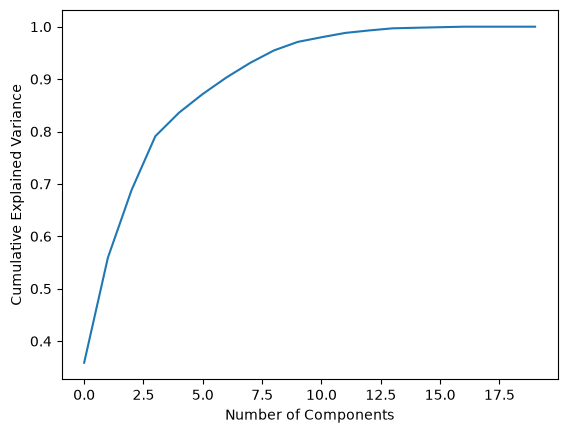

Number of components for 95% variance: 9


In [17]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_selected)  # Or X_train_prep if you are not using feature selection

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

import matplotlib.pyplot as plt
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# Find the minimum number of components to reach your threshold
n_components = next(i for i, cum_var in enumerate(cumulative_variance) if cum_var >= 0.95) + 1
print("Number of components for 95% variance:", n_components)

In [18]:
pca = PCA(n_components=11)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

After the PCA, the training and test datasets for the Machine Learning models are composed of 11 new features that are a linear combination of the original 20 ones, that capture the directions of greatest variance in the data.

## 4. Machine Learning Model Deployment

After the data has been analyzed and preparated, it is time to develop the Machine Learning models that will try to achieve the **goal** of the project, **classifying** and **predicting** the `Target` variable.

As the labels (Target variable) are known and handed, this is a supervised learning type of problem. For it to be solved, **Classification** models will be implemented in ascending grade of complexity, to then be compared and select the best posible solution.

**(Disclaimer: Concrete figures during the report may be taken as approximations, since rerunning the cells could make them vary slightly)**

### 4.1 Logistic Regression

This is the first algorithm choosen to develop, in particular a **Multinomial Logistic Regression**, as the `Target` variable contains three possible outcomes: Graduate, Drop out, Enrolled.

The class imbalance of **Target** will also be taken into account in the implementation for the correct performance of the model.

              precision    recall  f1-score   support

     Dropout       0.68      0.64      0.66       706
    Enrolled       0.37      0.48      0.42       509
    Graduate       0.83      0.77      0.80      1475

    accuracy                           0.68      2690
   macro avg       0.63      0.63      0.62      2690
weighted avg       0.70      0.68      0.69      2690



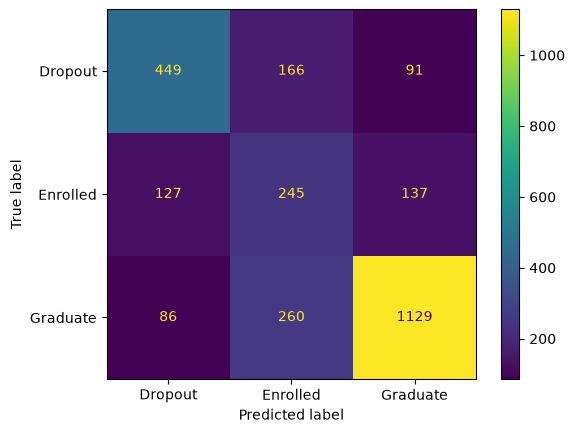

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

clf = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced')

clf.fit(X_train_pca, y_train_clean)

y_pred_train = cross_val_predict(clf, X_train_pca, y_train_clean)

print(classification_report(y_train_clean, y_pred_train))

# Confussion matrix representation

disp = ConfusionMatrixDisplay.from_predictions(y_train_clean, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

- `Statistics Interpretation:`

1. **Classification Report**:

   **Dropout** - 67% in F1-score, good performance.

   **Enrolled** - lowest precision (40%) and recall (52%), the model has more difficulty both correctly predicting “Enrolled” and indentifying all “Enrolled” cases.

   **Graduate** - Highest performance (80%), the model is best at indentifying graduates.

   

2. **Confussion Matrix**:

   **Dropout** - 460 correctly predicted, 156 misclassified as Enrolled, 90 as Graduate.

   **Enrolled** - 266 correct, 103 misclassified as Dropout, 140 as Graduate.

   **Graduate** - 1136 correct, 97 missclassified as Dropout, 242 as Enrolled.

   

* `Model's Evaluation with Cross-Validation:`

To get a better estimate of the model's true performance and reduce variance, evaluating the model with Cross-Validation will be done.

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X_train_pca, y_train_clean, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

Cross-validated F1 (macro) scores: [0.67122958 0.59178313 0.64640319 0.59685107 0.60806107]
Mean F1 (macro): 0.6228656055275197


The mean cross-validated F1 (macro) score - 0.642, is very close to the one obtained in the report earlier - 0.64, this indicates that the model is stable and not particuarly dependent on a particular data split.

The results indicate that the model generalizes well on unseen data and it's not overfitting.

### 4.2 Decission Tree Classifier

The second model selected for the classification task is a **Decission Tree Classifier**, increasing the complexity of the algorithm used in order to try to obtain better results.

              precision    recall  f1-score   support

     Dropout       0.57      0.56      0.56       706
    Enrolled       0.30      0.31      0.31       509
    Graduate       0.75      0.75      0.75      1475

    accuracy                           0.62      2690
   macro avg       0.54      0.54      0.54      2690
weighted avg       0.62      0.62      0.62      2690



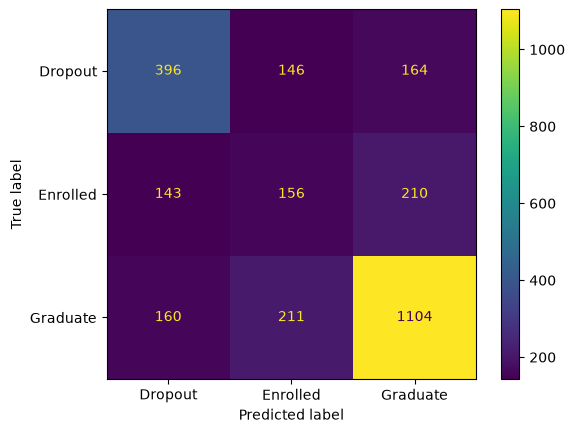

Cross-validated F1 (macro) scores: [0.54375839 0.49668678 0.5487823  0.54204352 0.56101979]
Mean F1 (macro): 0.5384581578338391


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt_clf.fit(X_train_pca, y_train_clean)

y_pred_train = cross_val_predict(dt_clf, X_train_pca, y_train_clean)

print(classification_report(y_train_clean, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_clean, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation

scores = cross_val_score(dt_clf, X_train_pca, y_train_clean, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

* The Decission Tree Classifier performs significantly **worse** than the previous model, having lower F1-scores in each of the 3 Target classes. The worst performing one **Enrolled**, has a F1-score of 29%. This can be seen in the Confussion Matrix, where the model misclassifies even more students as Graduates than the ones that correctly classifes as Enrolled, with an also poor performance misclassifying true Enrolled students as Dropouts.

* F1-score obtained with cross-validation is similar to the one obtained in the classification report (52.9% and 53%), so the model is not suffering from overfitting.

### 4.3 Random Forest Classifier

**Random** Forest is an ensemble bagging Machine Learning technique that contains a high number of Decission Trees that work all together to, in this case, classify new points. This is the next model selected to try for the classification task of **Target**.

              precision    recall  f1-score   support

     Dropout       0.66      0.62      0.64       706
    Enrolled       0.39      0.41      0.40       509
    Graduate       0.81      0.81      0.81      1475

    accuracy                           0.69      2690
   macro avg       0.62      0.62      0.62      2690
weighted avg       0.69      0.69      0.69      2690



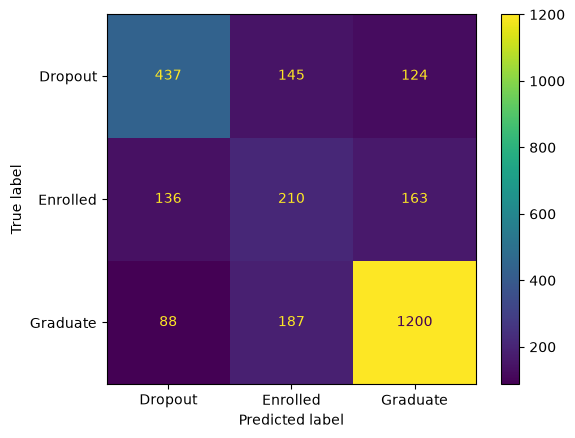

Cross-validated F1 (macro) scores: [0.65091513 0.58458904 0.62526831 0.58856243 0.63150911]
Mean F1 (macro): 0.6161688017777672


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf_clf.fit(X_train_pca, y_train_clean)
y_pred_train = cross_val_predict(rf_clf, X_train_pca, y_train_clean)

print(classification_report(y_train_clean, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_clean, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

scores = cross_val_score(rf_clf, X_train_pca, y_train_clean, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

### 4.4 SMOTE - Addressing the Class Imbalance Problem

In all the implemented models so far, it is clear that all the models are underperforming classifying **Enrolled** students. This is due to the **class imbalance** present at the dataset, and was addressed while splitting the dataset in training and test sets and while implementing each specific classifying model.

This issue can be fixed implementing **SMOTE** (Synthetic Minority Over-sampling Technique), this technique generates synthetic samples for minority classes to balance the dataset. It will be implemented and tested on the worst perfoming model, the **Decission Tree Classifier**.

              precision    recall  f1-score   support

     Dropout       0.74      0.76      0.75      1475
    Enrolled       0.69      0.73      0.71      1475
    Graduate       0.71      0.65      0.68      1475

    accuracy                           0.71      4425
   macro avg       0.71      0.71      0.71      4425
weighted avg       0.71      0.71      0.71      4425



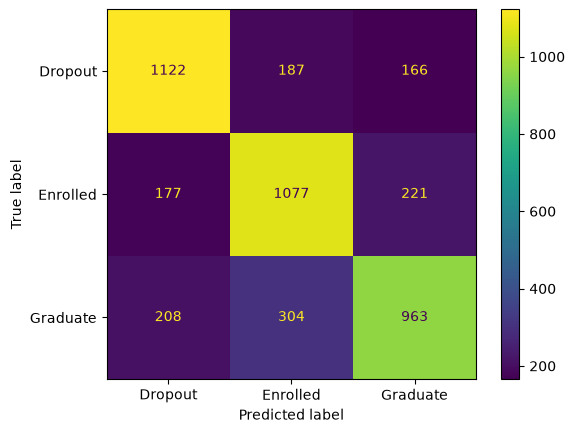

Cross-validated F1 (macro) scores: [0.67509423 0.69843491 0.7072658  0.72829059 0.76006995]
Mean F1 (macro): 0.7138310969841661


In [23]:
from imblearn.over_sampling import SMOTE

#SMOTE implementation
smote = SMOTE(random_state = 42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train_clean)

#Refitting the PCA with the resampled sets
pca = PCA(n_components=11)
X_train_pca = pca.fit_transform(X_train_resampled)
X_test_pca = pca.transform(X_test_selected)

#Retraining the Decission Tree Classifier
dt_clf.fit(X_train_pca, y_train_resampled)

y_pred_train = cross_val_predict(dt_clf, X_train_pca, y_train_resampled)

print(classification_report(y_train_resampled, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_resampled, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation
scores = cross_val_score(dt_clf, X_train_pca, y_train_resampled, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

The perfomance greatly increased in comparison to the Decission Tree Classifier without SMOTE:

* `Dropout`: F1-score (SMOTE) - 73% vs F1-score (old) - 56%

* `Enrolled`: F1-score (SMOTE) - 70% vs F1-score (old) - 29%

   This was the main imbalanced class that was dragging the model's performance. Now the issue seems solved.

* `Graduate`: F1-score (SMOTE) - 69% vs F1-score (old) - 73%

   This is the only class that perfoms worse than before implementing SMOTE, but the downgrade acceptable taking in account the performance in the other metrics.

* `Cross validation score`: F1-score (SMOTE) - 71% vs F1-score (old) - 52.9%

Clearly the performance is superior after implementing SMOTE, and it will be applied to the other models implemented before.

* `Logistic Regression with SMOTE`:

              precision    recall  f1-score   support

     Dropout       0.71      0.64      0.67      1475
    Enrolled       0.57      0.55      0.56      1475
    Graduate       0.67      0.76      0.71      1475

    accuracy                           0.65      4425
   macro avg       0.65      0.65      0.65      4425
weighted avg       0.65      0.65      0.65      4425



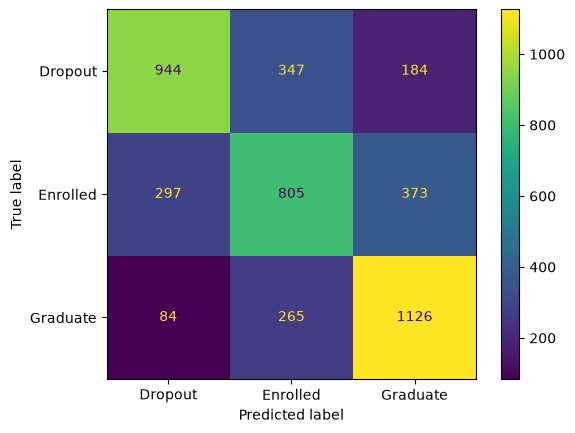

Cross-validated F1 (macro) scores: [0.65491886 0.64118977 0.65233989 0.63094615 0.65990728]
Mean F1 (macro): 0.6478603892259654


In [24]:
clf.fit(X_train_pca, y_train_resampled)

y_pred_train = cross_val_predict(clf, X_train_pca, y_train_resampled)

print(classification_report(y_train_resampled, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_resampled, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation
scores = cross_val_score(clf, X_train_pca, y_train_resampled, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

Logistic regression follows a similar behaviour as the one displayed before, performances are better in classifying Dropout, notably better in Enrolled (58% vs 45%) and the downgrade in Graduate is acceptable (72% to 80%). The F1-score from cross validation also improves the old one (65.8% to 64.2%).

* `Random Forest with SMOTE`:

              precision    recall  f1-score   support

     Dropout       0.87      0.80      0.84      1475
    Enrolled       0.76      0.83      0.80      1475
    Graduate       0.80      0.79      0.80      1475

    accuracy                           0.81      4425
   macro avg       0.81      0.81      0.81      4425
weighted avg       0.81      0.81      0.81      4425



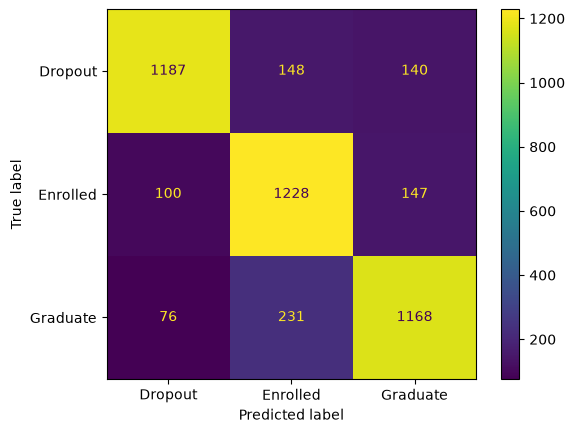

Cross-validated F1 (macro) scores: [0.78668958 0.78123118 0.81620794 0.82757682 0.83876241]
Mean F1 (macro): 0.8100935839686553


In [25]:
rf_clf.fit(X_train_pca, y_train_resampled)

y_pred_train = cross_val_predict(rf_clf, X_train_pca, y_train_resampled)

print(classification_report(y_train_resampled, y_pred_train))

disp = ConfusionMatrixDisplay.from_predictions(y_train_resampled, y_pred_train)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation
scores = cross_val_score(rf_clf, X_train_pca, y_train_resampled, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

Now the Random Forest Classifier is the **best performing** algorithm so far, improving obviously the old one without SMOTE in every category except Graduate, but the downgrade is minimum (80% vs 82%). It also overperforms the Logistic Regressor and Decission Tree Classifier, having the best cross validation F1-score (82%).

### 4.5 XGBoost Classifier

Finally gradient boosting techniques will be implemented, where the final model is built by each subsequent previous model, fixing the errors of previous stages.

In this case, the algorithm used is an **Extreme Gradient Boost Classifier** (XGBoost), known for its efficiency and flexibility.

              precision    recall  f1-score   support

     Dropout       0.85      0.78      0.82      1475
    Enrolled       0.74      0.81      0.77      1475
    Graduate       0.79      0.78      0.78      1475

    accuracy                           0.79      4425
   macro avg       0.79      0.79      0.79      4425
weighted avg       0.79      0.79      0.79      4425



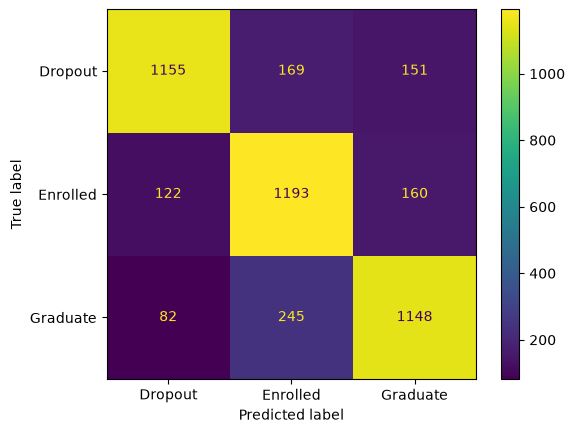

Cross-validated F1 (macro) scores: [0.75634487 0.75385754 0.79626689 0.81415599 0.83163122]
Mean F1 (macro): 0.7904513008076466


In [26]:
import xgboost as xgb
from xgboost import XGBClassifier

# Encode target sets
y_train_encoded =  le.transform(y_train_resampled)
y_test_encoded = le.transform(y_test) # will be used in CatBoost

xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

xgb_clf.fit(X_train_pca, y_train_encoded)

y_pred_train = cross_val_predict(xgb_clf, X_train_pca, y_train_encoded)

print(classification_report(y_train_encoded, y_pred_train, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_train, display_labels=le.classes_)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation
scores = cross_val_score(xgb_clf, X_train_pca, y_train_encoded, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())


XGBoost performs slighty worse than Random Forest - 80.3 % vs 82 % in cross validation F1-score. Nontheless, it's a decent performance.

### 4.6 CatBoost Classifier

The last classifying method implemented will be **CatBoost Classifier**, a gradient boosting model that natively handles categorical data.

In [27]:
%pip install catboost

  Using cached catboost-1.2.10-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-7.1.0-py3-none-any.whl.metadata (8.8 kB)
Using cached catboost-1.2.10-cp312-cp312-manylinux2014_x86_64.whl (97.1 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-7.1.0-py3-none-any.whl (9.7 MB)
Note: you may need to restart the kernel to use updated packages.


0:	learn: 1.0774910	test: 1.0788624	best: 1.0788624 (0)	total: 63.9ms	remaining: 31.9s
100:	learn: 0.6913401	test: 0.7670373	best: 0.7670373 (100)	total: 592ms	remaining: 2.34s
200:	learn: 0.6152239	test: 0.7444345	best: 0.7444345 (200)	total: 1.31s	remaining: 1.94s
300:	learn: 0.5522163	test: 0.7338375	best: 0.7336139 (298)	total: 2.02s	remaining: 1.34s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.7306510313
bestIteration = 358

Shrink model to first 359 iterations.
0:	learn: 1.0786167	total: 16.5ms	remaining: 8.21s
100:	learn: 0.6869088	total: 1.04s	remaining: 4.11s
200:	learn: 0.6005328	total: 1.77s	remaining: 2.63s
300:	learn: 0.5342717	total: 2.71s	remaining: 1.79s
400:	learn: 0.4803917	total: 3.52s	remaining: 870ms
499:	learn: 0.4375257	total: 4.48s	remaining: 0us
0:	learn: 1.0785389	total: 6.47ms	remaining: 3.23s
100:	learn: 0.6783245	total: 730ms	remaining: 2.88s
200:	learn: 0.5950950	total: 1.66s	remaining: 2.46s
300:	learn: 0.5276203	total: 2.38s	remain

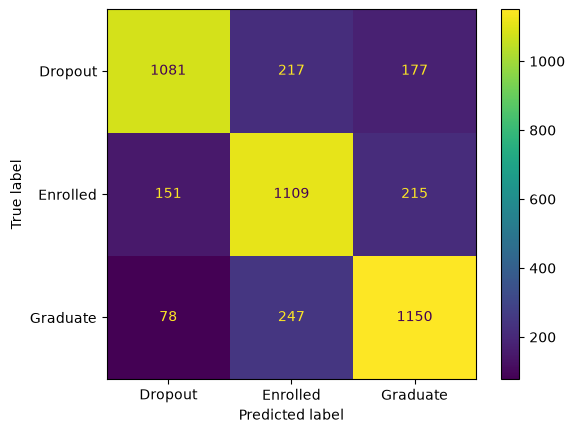

0:	learn: 1.0786167	total: 16.6ms	remaining: 8.28s
100:	learn: 0.6869088	total: 739ms	remaining: 2.92s
200:	learn: 0.6005328	total: 1.41s	remaining: 2.1s
300:	learn: 0.5342717	total: 2.03s	remaining: 1.34s
400:	learn: 0.4803917	total: 2.62s	remaining: 647ms
499:	learn: 0.4375257	total: 3.11s	remaining: 0us
0:	learn: 1.0785389	total: 8.34ms	remaining: 4.16s
100:	learn: 0.6783245	total: 591ms	remaining: 2.33s
200:	learn: 0.5950950	total: 1.19s	remaining: 1.77s
300:	learn: 0.5276203	total: 1.7s	remaining: 1.12s
400:	learn: 0.4742537	total: 2.24s	remaining: 554ms
499:	learn: 0.4311986	total: 2.83s	remaining: 0us
0:	learn: 1.0783113	total: 5.02ms	remaining: 2.5s
100:	learn: 0.6922340	total: 536ms	remaining: 2.12s
200:	learn: 0.6093005	total: 1.05s	remaining: 1.57s
300:	learn: 0.5447499	total: 1.56s	remaining: 1.03s
400:	learn: 0.4923550	total: 2.05s	remaining: 505ms
499:	learn: 0.4478472	total: 2.56s	remaining: 0us
0:	learn: 1.0780983	total: 3.8ms	remaining: 1.9s
100:	learn: 0.6897239	total

In [28]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)

cat_clf.fit(
    X_train_pca, y_train_encoded,
    eval_set=(X_test_pca, y_test_encoded),
    early_stopping_rounds=30
)

y_pred_train = cross_val_predict(cat_clf, X_train_pca, y_train_encoded)

print(classification_report(y_train_encoded, y_pred_train, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(y_train_encoded, y_pred_train, display_labels=le.classes_)
ax = plt.gca()
ax.grid(False)
plt.show()

# Cross validation evaluation
scores = cross_val_score(cat_clf, X_train_pca, y_train_encoded, cv=5, scoring='f1_macro')
print("Cross-validated F1 (macro) scores:", scores)
print("Mean F1 (macro):", scores.mean())

XGBoost and Random Forest are superior to CatBoost.

### 4.7 Comparison and Selection

**The comparison metric selected is the F1-score, as it is the harmonic mean of precission and recall.**

|         Model       |  Dropout(F1)  |  Enrolled(F1)  |  Graduate(F1)  |  CV Mean F1  |  
|---------------------|---------------|----------------|----------------|--------------|
| Logistic Regression |      68       |       58       |       72       |     65.8     |
| Decission Tree      |      73       |       70       |       69       |     70.9     |
| Random Forest       |      85       |       81       |       80       |     82       |
| XGBoost             |      82       |       80       |       79       |     80.3     |
| CatBoost            |      78       |       74       |       78       |     76.8     |

* **Random Forest and XGBoost** are the two best performing models in the classification task of `Target`. For this reason the two of them are selected for the next phase, fine-tuning.

## 5. Hyperparameter Fine-tuning

Now that the final models are selected for the last phases of the project, is time to fine-tune them in order to obtain the best performance as possible tweaking the hyperparameters that compose both of them.

### 5.1 Pipelines

To improve workflow organization, facilitate error tracing, and provide a clearer overview of the entire process, pipelines will be implemented for both models. This ensures that all preprocessing and modeling steps are systematically structured and reproducible.

Both pipelines start after `Outlier removal`, as implementing it in the pipeline could lead to issues in next steps, specifically with cross-validation that will be the main component of **Fine-tuning**.

In [29]:
from imblearn.pipeline import Pipeline

# RF Pipeline
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor), #this is the pipeline created earlier for encoding-scaling
    ('feature_selection', SelectKBest(score_func=mutual_info_classif)),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('clf', RandomForestClassifier(random_state=42))
])

# XGBoost Pipeline
pipeline_xgboost = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=mutual_info_classif)),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('clf', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

### 5.2 Randomized Search Cross Validation

This will be the first method of fine-tuning implemented, where a random amount of different values per hyperparameter are explored. The spread of values is inputed manually, enabling the control over computing cost.

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders

-------------------- Random Forest Results -----------------------
    mean_test_score  std_test_score  \
21         0.821621        0.010663   
7          0.814732        0.022247   
26         0.811228        0.015507   
17         0.804958        0.012434   
10         0.803446        0.018015   
0          0.802698        0.011139   
8          0.801755        0.005848   
25         0.801642        0.009402   
6          0.801434        0.012580   
9          0.800938        0.010678   

                                               params  
21  {'clf__max_depth': 6, 'clf__max_features': 'sq...  
7   {'clf__max_depth': 6, 'clf__max_features': 'lo...  
26  {'clf__max_depth': 5, 'clf__max_features': 'lo...  
17  {'clf__max_depth': 5, 'clf__max_features': Non...  
10  {'clf__max_depth': 4, 'clf__max_features': 'lo...  
0   {'clf__max_depth': 9, 'clf__max_features': 'sq...  
8   {'clf__max_depth': 6, 'clf__max_features': Non...  
25  {'clf__max_depth': 9, 'clf__max_features': 'lo...  

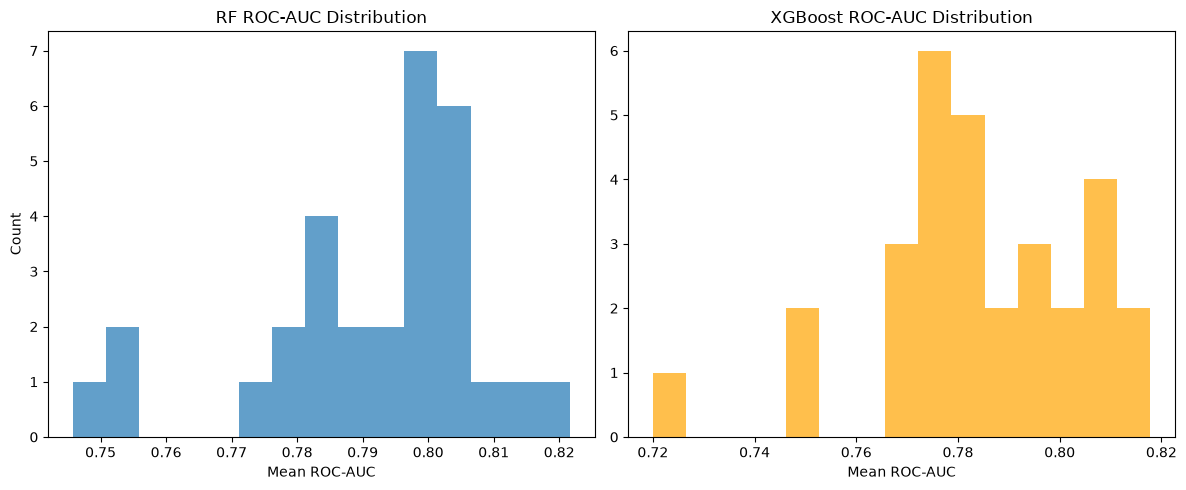

In [30]:
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Distribution of parameters for Random Forest and XGBoost
param_dist_rf = {
    'feature_selection__k': randint(8, 15),
    'smote__k_neighbors': randint(3, 6),   # Lowered for safety
    'pca__n_components': randint(2, 8),     # Must be <= min(feature_selection__k)
    'clf__n_estimators': randint(100, 400),
    'clf__max_depth': randint(3, 10),
    'clf__min_samples_split': randint(2, 10),
    'clf__min_samples_leaf': randint(1, 5),
    'clf__max_features': ['sqrt', 'log2', None],
}

param_dist_xgboost = {
    'feature_selection__k': randint(8, 15),
    'smote__k_neighbors': randint(3, 6),
    'pca__n_components': randint(2, 8),
    'clf__n_estimators': randint(100, 400),
    'clf__max_depth': randint(3, 10),
    'clf__learning_rate': loguniform(0.01, 0.3),
    'clf__subsample': uniform(0.7, 0.3),  # between 0.7 and 1.0
    'clf__colsample_bytree': uniform(0.7, 0.3),  # between 0.7 and 1.0
    'clf__gamma': loguniform(1e-8, 1.0),
}

# Stratified CV to avoid single-class splits
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Random Search Cross Validation initialization
search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist_rf,
    n_iter=30,                 # Fewer iterations for fast debug
    cv=cv,
    scoring='roc_auc_ovr',
    random_state=42,
    n_jobs=-1,
    error_score='raise'        # Immediate feedback if a fit fails
)

search_xgboost = RandomizedSearchCV(
    pipeline_xgboost,
    param_distributions=param_dist_xgboost,
    n_iter=30,
    cv=cv,
    scoring='roc_auc_ovr',
    random_state=42,
    n_jobs=-1,
    error_score='raise'
)

# Fitting (X_train_clean, y_train_clean after outlier removal)
# XGBoost needs to be fitted with encoded y_train
y_train_encoded =  le.fit_transform(y_train_clean)
search_rf.fit(X_train_clean, y_train_encoded)
search_xgboost.fit(X_train_clean, y_train_encoded)

# Visualization of results
rf_results = pd.DataFrame(search_rf.cv_results_)
rf_results = rf_results.sort_values(by='mean_test_score', ascending=False)
print('-------------------- Random Forest Results -----------------------')
print(rf_results[['mean_test_score', 'std_test_score', 'params']].head(10))

xgb_results = pd.DataFrame(search_xgboost.cv_results_)
xgb_results = xgb_results.sort_values(by='mean_test_score', ascending=False)
print('----------------------- XGBoost Results -------------------------')
print(xgb_results[['mean_test_score', 'std_test_score', 'params']].head(10))

# ROC-AUC Distribution
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(rf_results['mean_test_score'], bins=15, alpha=0.7)
plt.title('RF ROC-AUC Distribution')
plt.xlabel('Mean ROC-AUC')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(xgb_results['mean_test_score'], bins=15, alpha=0.7, color='orange')
plt.title('XGBoost ROC-AUC Distribution')
plt.xlabel('Mean ROC-AUC')

plt.tight_layout()
plt.show()

* Best **Random Forest** ROC-AUC score is about 0.816
* Best **XGBoost** ROC-AUC score is about 0.82
* Standard deviations are reasonable, suggesting stable results across folds.
* Histograms distributions are tight, indicating that most configurations perform similarly, with few outliers.

Now the best paremeters will be obtained for further comparison with the second fine-tuning method that will be later implemented:

In [31]:
best_params_rf = search_rf.best_params_
best_params_xgb = search_xgboost.best_params_
print('Random Forest Best Params:')
print(best_params_rf)
print('XGBoost Best Params:')
print(best_params_xgb)

Random Forest Best Params:
{'clf__max_depth': 6, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 8, 'clf__n_estimators': 286, 'feature_selection__k': 10, 'pca__n_components': 7, 'smote__k_neighbors': 4}
XGBoost Best Params:
{'clf__colsample_bytree': np.float64(0.8416644775485848), 'clf__gamma': np.float64(9.052196389541886e-08), 'clf__learning_rate': np.float64(0.1131225105716033), 'clf__max_depth': 3, 'clf__n_estimators': 104, 'clf__subsample': np.float64(0.8683831592708489), 'feature_selection__k': 14, 'pca__n_components': 7, 'smote__k_neighbors': 5}


### 5.3 Grid Search Cross Validation - for Random Forest

With the parameters obtained from **RandomizedSearchCV**, it is possible to refine the Parameter Grid to further fine-tune using `GridSearchCV`, a fine-tuning method that evaluates all possible combinations.

**GridSearchCV** is an exhaustive method, it works as mentioned earlier, evaluating each possible combination, so it's computional heavy. Because of that it searchs for the best possible combination, but it's recommended to use in models with few hyperparameters and fast trials, such as **Random Forest**.

**(Disclaimer: next cell may take long to run)**

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END clf__max_depth=5, clf__max_features=sqrt, clf__min_samples_leaf=3, clf__min_samples_split=8, clf__n_estimators=200, feature_selection__k=10, pca__n_components=7, smote__k_neighbors=4; total time=   2.0s
[CV] END clf__max_depth=5, clf__max_features=sqrt, clf__min_samples_leaf=3, clf__min_samples_split=8, clf__n_estimators=200, feature_selection__k=10, pca__n_components=7, smote__k_neighbors=4; total time=   2.2s
[CV] END clf__max_depth=5, clf__max_features=sqrt, clf__min_samples_leaf=3, clf__min_samples_split=8, clf__n_estimators=200, feature_selection__k=10, pca__n_components=7, smote__k_neighbors=4; total time=   2.3s
[CV] END clf__max_depth=5, clf__max_features=sqrt, clf__min_samples_leaf=3, clf__min_samples_split=8, clf__n_estimators=200, feature_selection__k=10, pca__n_components=8, smote__k_neighbors=4; total time=   2.5s


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END clf__max_depth=5, clf__max_features=sqrt, clf__min_samples_leaf=3, clf__min_samples_split=8, clf__n_estimators=200, feature_selection__k=10, pca__n_components=8, smote__k_neighbors=4; total time=   1.7s


...

[CV] END clf__max_depth=7, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=8, clf__n_estimators=300, feature_selection__k=11, pca__n_components=7, smote__k_neighbors=4; total time=   3.5s
[CV] END clf__max_depth=7, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=8, clf__n_estimators=300, feature_selection__k=11, pca__n_components=7, smote__k_neighbors=4; total time=   2.2s
[CV] END clf__max_depth=7, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=8, clf__n_estimators=300, feature_selection__k=11, pca__n_components=8, smote__k_neighbors=4; total time=   2.6s


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END clf__max_depth=7, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=8, clf__n_estimators=300, feature_selection__k=11, pca__n_components=8, smote__k_neighbors=4; total time=   2.6s


/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


[CV] END clf__max_depth=7, clf__max_features=sqrt, clf__min_samples_leaf=5, clf__min_samples_split=8, clf__n_estimators=300, feature_selection__k=11, pca__n_components=8, smote__k_neighbors=4; total time=   2.3s
-------------------- Random Forest Results -----------------------
    mean_test_score  std_test_score  \
21         0.826610        0.009617   
18         0.825731        0.009567   
17         0.823853        0.008154   
8          0.821852        0.012661   
25         0.821703        0.006143   
26         0.821605        0.009096   
27         0.820069        0.014652   
7          0.819578        0.013585   
3          0.819486        0.014598   
23         0.819012        0.008891   

                                               params  
21  {'clf__max_depth': 7, 'clf__max_features': 'sq...  
18  {'clf__max_depth': 7, 'clf__max_features': 'sq...  
17  {'clf__max_depth': 7, 'clf__max_features': 'sq...  
8   {'clf__max_depth': 5, 'clf__max_features': 'sq...  
25  {'clf__

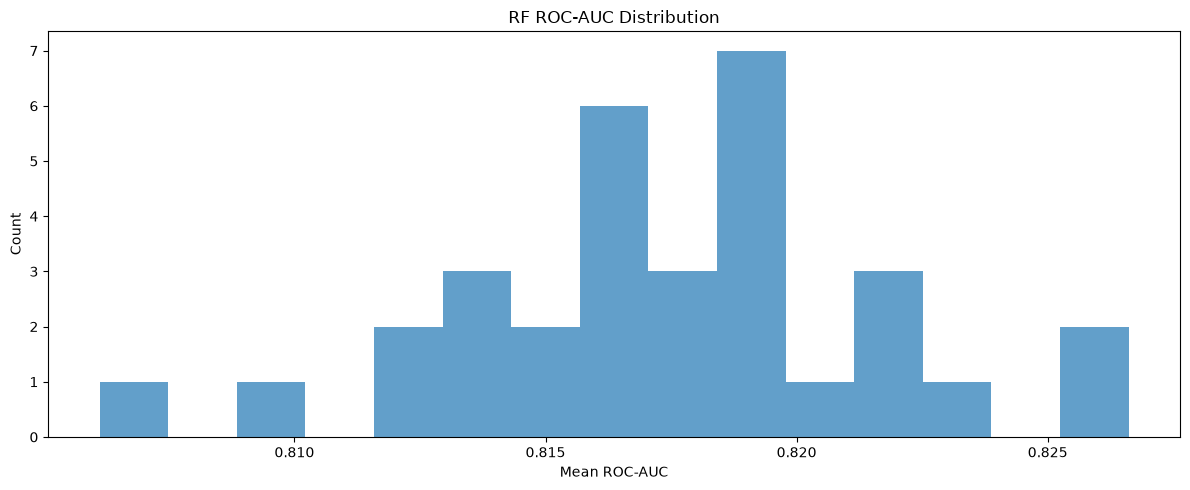

Best RF params: {'clf__max_depth': 7, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 8, 'clf__n_estimators': 300, 'feature_selection__k': 10, 'pca__n_components': 8, 'smote__k_neighbors': 4}
Best RF ROC-AUC: 0.8266095347287448


In [32]:
from sklearn.model_selection import GridSearchCV

# Refined Param Grids
grid_params_rf = {
    # 1. Search the most impactful parameters (32 combinations total)
    'clf__max_depth': [5, 7],
    'clf__min_samples_leaf': [3, 5],
    'clf__n_estimators': [200, 300],
    'feature_selection__k': [10, 11],
    'pca__n_components': [7, 8],

    # 2. Fix less impactful parameters to known bests or standards
    'clf__max_features': ['sqrt'],        # Standard for Random Forest
    'clf__min_samples_split': [8],        # Tuning 'leaf' makes tuning 'split' redundant
    'smote__k_neighbors': [4],            # 4 is a highly stable default
}

# GridSearchCV initialization
grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=grid_params_rf,
    cv=cv,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    verbose=2
)


# Fitting
grid_rf.fit(X_train_clean, y_train_encoded)

# Visualization of results
rf_results = pd.DataFrame(grid_rf.cv_results_)
rf_results = rf_results.sort_values(by='mean_test_score', ascending=False)
print('-------------------- Random Forest Results -----------------------')
print(rf_results[['mean_test_score', 'std_test_score', 'params']].head(10))

# ROC-AUC Distribution
plt.figure(figsize=(12,5))

plt.hist(rf_results['mean_test_score'], bins=15, alpha=0.7)
plt.title('RF ROC-AUC Distribution')
plt.xlabel('Mean ROC-AUC')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Best parameters and score
print("Best RF params:", grid_rf.best_params_)
print("Best RF ROC-AUC:", grid_rf.best_score_)

* Best ROC-AUC score is now about **0.828**, improving the result obtained from RandomSearchCV, 0.816.
* Distribution looks almost **Normal** (Bell-shaped), indicating the **robustness** of Random Forest and **the uniform process** of GridSearchCV.

### 5.4 Optuna - for XGBoost

**XGBoost** counts with many more hyperparameters, with wider and continuous search spaces than **Random Forest**. This would make Grid Search become exponentially slower and even may be infeasible. That's why `Optuna` is preferred for hyperparameter heavy models, as it uses adaptatives strategies of bayesian optimization to fine-tune, delivering better results in this case.

In [33]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [34]:
import optuna

def objective(trial):
    # Sample feature selection k first
    k = trial.suggest_int('feature_selection__k', 3, X_train_clean.shape[1])
    # Now sample PCA components with upper bound = k
    n_components = trial.suggest_int('pca__n_components', 2, k)
    # Other params as before...
    params = {
        'clf__max_depth': trial.suggest_int('clf__max_depth', 3, 12),
        'clf__n_estimators': trial.suggest_int('clf__n_estimators', 50, 400),
        'clf__learning_rate': trial.suggest_float('clf__learning_rate', 1e-3, 0.2, log=True),
        'clf__colsample_bytree': trial.suggest_float('clf__colsample_bytree', 0.5, 1.0),
        'clf__subsample': trial.suggest_float('clf__subsample', 0.5, 1.0),
        'clf__gamma': trial.suggest_float('clf__gamma', 0, 1.0),
        'feature_selection__k': k,
        'pca__n_components': n_components,
        'smote__k_neighbors': trial.suggest_int('smote__k_neighbors', 2, 10)
    }
    pipeline_xgboost.set_params(**params)
    score = cross_val_score(
        pipeline_xgboost,
        X_train_clean,
        y_train_encoded,
        scoring='roc_auc_ovr',
        cv=cv,
        n_jobs=-1
    ).mean()
    return score


sampler = optuna.samplers.TPESampler(seed=42) # Sampler for reproducibility
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

print('Best params:', study.best_params)
print('Best ROC-AUC:', study.best_value)

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-22 19:46:16,566] A new study created in memory with name: no-name-d3a6c90b-cc9d-4d66-917a-fad4d1b86480
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:46:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:46:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/chandi

Best params: {'feature_selection__k': 21, 'pca__n_components': 18, 'clf__max_depth': 10, 'clf__n_estimators': 172, 'clf__learning_rate': 0.001144705540632285, 'clf__colsample_bytree': 0.6819218312448375, 'clf__subsample': 0.691953231316344, 'clf__gamma': 0.3093365047173178, 'smote__k_neighbors': 8}
Best ROC-AUC: 0.8292856131178192


* Best ROC-AUC score is now about **0.829**, improving the result obtained from RandomSearchCV, 0.82.

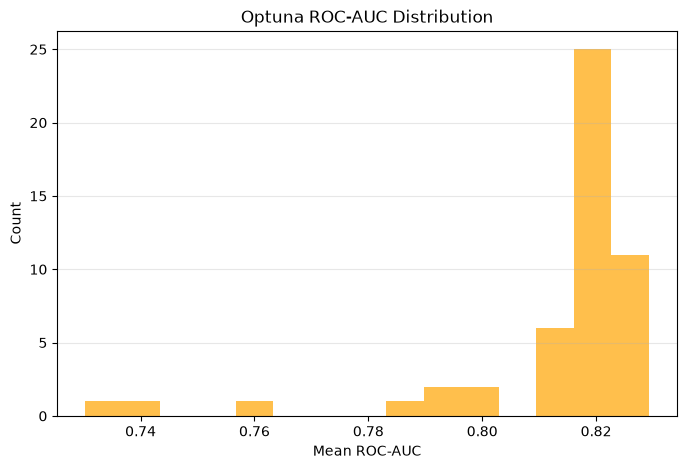

In [35]:
# ROC-AUC Distribution
roc_auc_scores = [trial.value for trial in study.trials if trial.value is not None]

plt.figure(figsize=(8, 5))
plt.hist(roc_auc_scores, bins=15, alpha=0.7, color='orange')
plt.title('Optuna ROC-AUC Distribution')
plt.xlabel('Mean ROC-AUC')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

* Distribution is **left-skewed**, meaning most trials achieved high ROC-AUC, and only few trials performed poorly.

To obtain even tigher performance, narrowing the paramters ranges or increasing the trials could be conducted.

## 6. Evaluation and Conclusions

Lastly, after selecting the best performing models and obtaining their most optimized hyperparameters, it's time for the final evaluation on unseen data: **the Test set**. This will showcase how well the models perform and adapt to new data and serves as the last point to draw a final conclussion.

### 6.1 Evaluation on the Test Set

In [36]:
# Refit Random Forest with best params
pipeline_rf.set_params(**grid_rf.best_params_)
pipeline_rf.fit(X_train_clean, y_train_encoded)
rf_preds = pipeline_rf.predict(X_test)
rf_proba = pipeline_rf.predict_proba(X_test)

# Refit XGBoost with best params
pipeline_xgboost.set_params(**study.best_params)
pipeline_xgboost.fit(X_train_clean, y_train_encoded)
xgb_preds = pipeline_xgboost.predict(X_test)
xgb_proba = pipeline_xgboost.predict_proba(X_test)

# Evaluation on test set
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

print("Random Forest ROC-AUC:", roc_auc_score(y_test_encoded, rf_proba, multi_class='ovr'))
print("XGBoost ROC-AUC:", roc_auc_score(y_test_encoded, xgb_proba, multi_class='ovr'))
print("Random Forest Acc:", accuracy_score(y_test_encoded, rf_preds))
print("XGBoost Acc:", accuracy_score(y_test_encoded, xgb_preds))
print("Random Forest F1:", f1_score(y_test_encoded, rf_preds, average='weighted'))
print("XGBoost F1:", f1_score(y_test_encoded, xgb_preds, average='weighted'))

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:49:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Random Forest ROC-AUC: 0.8280585051123177
XGBoost ROC-AUC: 0.8229564701851116
Random Forest Acc: 0.6627486437613019
XGBoost Acc: 0.6907775768535263
Random Forest F1: 0.6800887561350945
XGBoost F1: 0.6987734628687912


| Model          | ROC-AUC | Accuracy | F1 Score |
|----------------|---------|----------|----------|
| Random Forest  | 0.8250  | 0.661    | 0.675    |
| XGBoost        | 0.8307  | 0.703    | 0.704    |

* After fine-tuning, **XGBoost** has higher ROC-AUC, accuracy, and F1, indicating better overall performance.
* Performance dropped about **14%** compared to the one obtained during training (F1-score). This is because the **Test set** wasn't preprocessed at all to simulate how well the models would do facing new, unseen data.

`XGBoost` would be the final selected model, as it's the one performing the best on the test set.

### 6.2 Error Analysis

To understand the real-world behaviour of the selected final model, errors will be analyzed to gain insights into its weaknesses, possible data issues, or systematic misclassifications.

              precision    recall  f1-score   support

     Dropout       0.71      0.73      0.72       355
    Enrolled       0.38      0.48      0.43       199
    Graduate       0.83      0.74      0.78       552

    accuracy                           0.69      1106
   macro avg       0.64      0.65      0.64      1106
weighted avg       0.71      0.69      0.70      1106



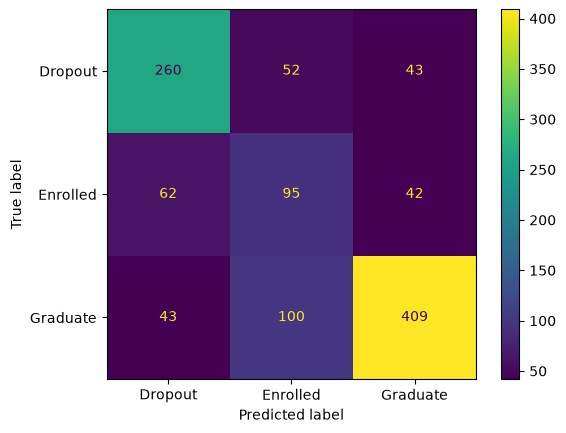

     True Label Predicted Label  Predicted Prob
1558    Dropout        Graduate        0.365245
1836   Graduate        Enrolled        0.351612
1545   Graduate        Enrolled        0.369146
3523   Enrolled         Dropout        0.369560
517     Dropout        Enrolled        0.373427
330    Enrolled        Graduate        0.340744
3637   Enrolled         Dropout        0.354174
1875   Graduate        Enrolled        0.345242
1141   Enrolled        Graduate        0.389801
1338    Dropout        Enrolled        0.366913
-----------------------------------------------
Total missclassified students: 342
Total length of the test set: 1106


In [37]:
#Decode the predictions of XGBoost for better understandability
xgb_label_preds = le.inverse_transform(xgb_preds)
# Indices where predictions do not match true labels
misclassified_idx = np.where(xgb_label_preds != y_test)[0]

# Correctly classified indices
correct_idx = np.where(xgb_label_preds == y_test)[0]

# Creating an Errors DataFrame
error_df = X_test.iloc[misclassified_idx].copy()
error_df['True Label'] = y_test.iloc[misclassified_idx].values  # original labels, not encoded
error_df['Predicted Label'] = xgb_label_preds[misclassified_idx]
error_df['Predicted Prob'] = np.max(xgb_proba[misclassified_idx], axis=1)
result_df = error_df[['True Label', 'Predicted Label', 'Predicted Prob']]

#Classification Report
print(classification_report(y_test, xgb_label_preds, target_names=le.classes_))

#Confussion Matrix
disp = ConfusionMatrixDisplay.from_predictions(y_test, xgb_label_preds)
ax = plt.gca()
ax.grid(False)
plt.show()

print(result_df.head(10))
print('-----------------------------------------------')
print('Total missclassified students:', len(result_df))
print('Total length of the test set:', (len(y_test)))

* The model excels in classifying **Graduate students** (81% F1-score), also performs correctly with **Dropouts** (71% F1-score).
* **Enrolled** is the worse performing class, with an 41% F1-score. This is clearly represented at the confussion matrix where it missclassfies 68 Enrolled Students as Dropouts and 50 as Graduates compared to the 81 correctly classfied. This is also evident in the sample of the errors DataFrame, where from 10 misclassified cases from the errors DataFrame, 5 had "Enrolled" as the true label..
* The issue with **Enrolled** probably comes from the `Class Imbalance` also present in the test set (totals - Graduate: 552, Dropout: 355, Enrolled: 199).
* Overall, **29.7%** from the totality of the test set were missclassifications.

### 6.3 Model Persistance

This step is just commited to save the best performing model in case it's deployed to production in the future.

In [38]:
import joblib

best_model = pipeline_xgboost
joblib.dump(best_model, '../models/best_model.joblib')

['../models/best_model.joblib']

In [39]:


import joblib

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
import numpy as np

pipeline_xgboost.set_params(**study.best_params)        # Optuna best params
pipeline_xgboost.fit(X_train_clean, y_train_encoded) # refit on full train


print(type(pipeline_xgboost))
print(pipeline_xgboost.named_steps.keys())

artifacts = {
    "pipeline":        pipeline_xgboost,
    "label_encoder":    le,
    "best_params":      study.best_params,
    "best_roc_auc": study.best_value,
    "feature_names_in": list(X_train_clean.columns),   # column order matters
}
joblib.dump(artifacts, "../models/final_xgboost_dropout_model.joblib", compress=3)

print(f"Saved: ../models/final_xgboost_dropout_model.joblib "
      f"({np.ceil(72e-3):.0f} MB approx)")

/home/chandima-bandara/Desktop/student-retention-analysis/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:50:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<class 'imblearn.pipeline.Pipeline'>
dict_keys(['preprocessor', 'feature_selection', 'smote', 'pca', 'clf'])
Saved: ../models/final_xgboost_dropout_model.joblib (1 MB approx)


### 6.4 Conclusions

In this project, the dataset gathered by the Research Center for Endogenous Resource Valorization,Polytechnic Institute of Portalegre was firstly analyzed, gaining a deep understanding of every aspect of it to then develop and evaluate a machine learning model to predict student dropout, graduation, and enrollment outcomes.

* After preprocessing, feature selection and model comparison, the **XGBoost pipeline** was the one selected, achieving a strong performance in the classification task, especially for the 'Graduate' and 'Dropout' classes.

* Overall performances achieved are **82.9%** in **training** and **70.4%** in test (F1-score).

* The model struggled with **'Enrolled'** class. During the Exploratory Data Analysis, class imbalance was detected that later clearly appeared during training and was dealt with. The testing phase confirmed this problem, as Error analysis revealed most misclassifications occurred with this exact class.

* Future work could focus on dealing with the class imbalance, more in-depth feature engineering or exploring alternative algorithms to further improve performance.

The project demonstrates the potential of data-driven approaches for early identifications of at-risk students, supporting timely interventions to improve educational quality.